# 04 阶次分析：变转速工况

**本节目标**

1. 生成一段转速从 1200 rpm 匀加速到 1800 rpm 的外圈故障信号；
2. 观察普通包络谱上的"频率涂抹"现象——谱峰变宽、位置模糊；
3. 对包络做角域重采样 + 阶次谱，验证主峰落在外圈理论阶次 3.5848 附近。

**原理**（详见 [docs/05 阶次分析](../docs/05_order_analysis.md)）

恒速时冲击近似等时间间隔，频谱上是尖锐谱线；变速时冲击**等角度**出现，
等时间采样信号的频谱被"涂抹"。阶次分析以轴相位 $\theta(t)$ 为主变量，
把信号重采样到等角度域再做 FFT，横轴变成**阶次**（每转次数）：

$$\text{故障阶次} = \frac{f_{fault}}{f_r} = \text{常数（与转速无关）}$$

例如外圈故障阶次 = BPFO / $f_r$ ≈ 107.36 / 29.95 = 3.5848，无论转速多少都不变。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from bearing_fault import (Bearing, BearingSimulator, envelope_analysis,
                           envelope_spectrum, order_spectrum)
from bearing_fault.plotting import plot_order_spectrum, plot_spectrum

FS, DURATION, SEED = 12000, 4.0, 1
bearing = Bearing.sk6205()
# 故障阶次是几何常数，与转速无关
char_orders = {k: v / 1.0 for k, v in
               bearing.characteristic_frequencies(1.0).items()}  # fr=1 Hz 时频率即阶次
print("理论故障阶次（次/转）：")
for name, o in char_orders.items():
    print(f"  {name:6s} {o:.4f}")

理论故障阶次（次/转）：
  cage   0.3983
  ball   2.3567
  inner  5.4152
  outer  3.5848


## 生成变速信号

`speed_ramp=(1200, 1800)` 表示转速从 1200 rpm 匀加速到 1800 rpm。
仿真器内部以轴相位 $\theta(t)$ 为主变量生成冲击（等角度间隔），
并返回 $\theta(t)$ 供阶次分析使用——真实场景下 $\theta(t)$ 来自转速计/键相信号。

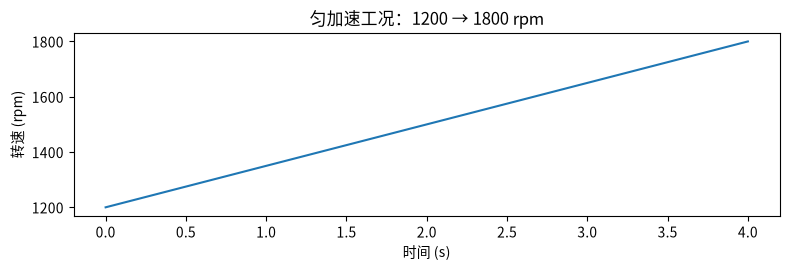

In [2]:
comp = BearingSimulator(fs=FS, duration=DURATION, rpm=1500, seed=SEED).signal(
    "outer", snr_db=-6.0, speed_ramp=(1200, 1800), return_components=True)
x, t, theta = comp["signal"], comp["t"], comp["theta"]

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot(t, comp["fr_t"] * 60, color="tab:blue")
ax.set_xlabel("时间 (s)")
ax.set_ylabel("转速 (rpm)")
ax.set_title("匀加速工况：1200 → 1800 rpm")
fig.tight_layout()
plt.show()

## 普通包络谱：频率涂抹

转速变化使 BPFO 从 $3.5848 \times 20 = 71.7$ Hz 漂移到 $3.5848 \times 30 = 107.5$ Hz。
包络谱上的谱峰被"涂抹"成一个宽峰，无法与任何固定频率对应——
基于固定频率的谱峰匹配在这种工况下会失效。

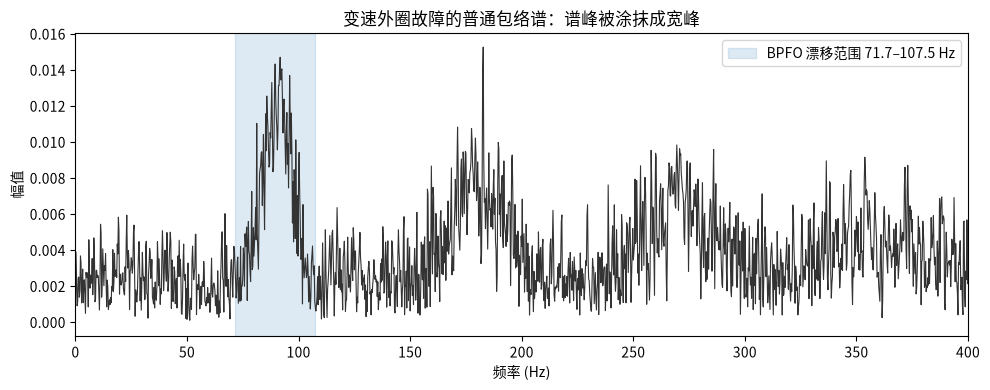

In [3]:
env = envelope_analysis(x, FS)["envelope"]
env_freqs, env_amps = envelope_spectrum(env, FS)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(env_freqs, env_amps, lw=0.8, color="0.2")
ax.axvspan(char_orders["outer"] * 20, char_orders["outer"] * 30,
           color="tab:blue", alpha=0.15,
           label=f"BPFO 漂移范围 {char_orders['outer']*20:.1f}–{char_orders['outer']*30:.1f} Hz")
ax.set_xlim(0, 400)
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("幅值")
ax.set_title("变速外圈故障的普通包络谱：谱峰被涂抹成宽峰")
ax.legend()
fig.tight_layout()
plt.show()

## 阶次谱：涂抹消失，主峰锁定理论阶次

`order_spectrum` 先按 $\theta(t)$ 把包络重采样到等角度域（每转 512 点），再做 FFT。
横轴变为阶次后，被涂抹的宽峰重新收拢成尖锐谱线。

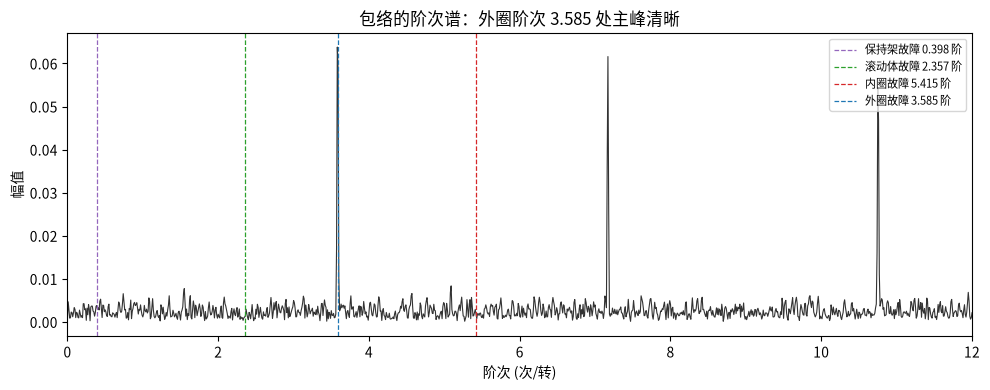

In [4]:
orders, order_amps = order_spectrum(env, theta, samples_per_rev=512)
plot_order_spectrum(orders, order_amps, char_orders=char_orders,
                    xlim=(0, 12), title="包络的阶次谱：外圈阶次 3.585 处主峰清晰")
plt.show()

In [5]:
# 定量验证：主峰阶次 vs 理论外圈阶次
sel = orders > 0.5   # 排除低频段
o_peak = orders[sel][np.argmax(order_amps[sel])]
o_theory = char_orders["outer"]
err = abs(o_peak - o_theory) / o_theory
print(f"阶次谱主峰：{o_peak:.4f} 阶")
print(f"外圈理论阶次：{o_theory:.4f} 阶")
print(f"相对误差：{err*100:.2f}%（要求 ±2% 以内）")
assert err < 0.02

阶次谱主峰：3.5801 阶
外圈理论阶次：3.5848 阶
相对误差：0.13%（要求 ±2% 以内）


**小结**：变速工况下，"频率"不再是好的坐标，"阶次"才是。
角域重采样把等时间信号变换到等角度域，故障特征从涂抹的宽峰恢复为固定阶次处的谱线。
注意阶次分析依赖准确的轴相位 $\theta(t)$，工程中由键相传感器或转速估计算法提供。

→ 下一节：[05 时频分析](05_time_frequency.ipynb)